In [1]:
import re
import pandas as pd
import torch
import numpy as np
from tqdm import tqdm
from torch.nn.functional import pad
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import matplotlib.pyplot as plt

In [3]:
model_id = "fine-tuned-gpt2-speakers-6"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model : GPT2LMHeadModel = GPT2LMHeadModel.from_pretrained(model_id).to(device)
tokenizer : GPT2TokenizerFast = GPT2TokenizerFast.from_pretrained(model_id)

spk1_id = tokenizer.convert_tokens_to_ids("<SPK1>")
spk2_id = tokenizer.convert_tokens_to_ids("<SPK2>")

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [4]:
def p1_new(dialog):
    max_length = model.config.n_positions
    stride = 1
    encodings = tokenizer("".join(dialog), return_tensors="pt")
    seq_len = encodings.input_ids.size(1)
    nlls = []
    for end_loc in tqdm(range(1, seq_len + 1, stride)):
        begin_loc = max(end_loc - max_length, 0)
        input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)
        target_ids = input_ids.clone()
        target_ids[:, :-stride] = -100

        with torch.no_grad():
            outputs = model(input_ids, labels=target_ids)
            neg_log_likelihood = outputs.loss

        nlls.append(neg_log_likelihood.item())

    return nlls

In [5]:
def create_extended_list(lst, arr):
    result = []
    prev_count = 0
    for i, count in enumerate(arr):
        result.extend([lst[i]] * (count - prev_count))
        prev_count = count
    return result

def compute_p3(dialog, perplexity_scores_p1):
    assert len(perplexity_scores_p1) == tokenizer("".join(dialog), return_tensors="pt", return_offsets_mapping=True).input_ids.size(1)
    tokens = [tokenizer(section, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for section in dialog]
    assert len(torch.cat(tokens)) == len(perplexity_scores_p1)
    tokens_ids_per_sentence = np.cumsum([t.size(0) for t in tokens])
    value = np.asarray([0] + list(np.asarray(perplexity_scores_p1)[tokens_ids_per_sentence[:-1]]))
    tokens_value = np.asarray([0] + list(np.asarray(torch.cat(tokens))[tokens_ids_per_sentence[:-1]]))
    perplexity_scores_p3 = create_extended_list(value, tokens_ids_per_sentence)
    assert len(perplexity_scores_p3) == tokenizer("".join(dialog), return_tensors="pt", return_offsets_mapping=True).input_ids.size(1)

    return perplexity_scores_p3

def mean_p_per_speaker(tokens, perplexity_scores):
    spk1 = []
    spk2 = []
    start = 0

    for i, token_tensor in enumerate(tokens):
        length = len(token_tensor)
        segment = perplexity_scores[start:start + length]
        avg_value = np.nanmean(segment)

        if token_tensor[0] == spk1_id:
            spk1.append(avg_value)
        elif token_tensor[0] == spk2_id:
            spk2.append(avg_value)
        else:
            raise ValueError(f"Wrong speaker token detected. {token_tensor.input_ids[0]}")
        start += length

    return (np.mean(spk1), np.mean(spk2))

def p1_use_next_token_ppl_for_speaker_begin_token(tokens, perplexity_scores):
    new_perplexity_scores = []
    for i, token in enumerate(torch.cat(tokens)):
        if token in [spk1_id, spk2_id]:
            new_perplexity_scores.append(perplexity_scores[i+1])
        else:
            new_perplexity_scores.append(perplexity_scores[i])
    
    return new_perplexity_scores

def p3_new(dialog):
    max_length = model.config.n_positions
    # Fixed stride = 1 in this code
    # stride = 1
    encodings = tokenizer("".join(dialog), return_tensors="pt")
    seq_len = encodings.input_ids.size(1)

    replace_token = spk1_id
    nlls = []
    for end_loc in tqdm(range(1, seq_len + 1)):
        # find replace token
        if encodings.input_ids[0, end_loc-1] == spk2_id:
            replace_token = spk2_id
        elif encodings.input_ids[0, end_loc-1] == spk1_id:
            replace_token = spk1_id

        begin_loc = max(end_loc - max_length, 0)
        input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)

        # replace token
        input_ids[:, -1] = replace_token
        
        target_ids = input_ids.clone()
        target_ids[:, :-1] = -100

        with torch.no_grad():
            outputs = model(input_ids, labels=target_ids)
            neg_log_likelihood = outputs.loss

        nlls.append(neg_log_likelihood.item())

    return nlls

def agg_p3_new(tokens, perplexity_scores):
    new_perplexity_scores = []
    start = 0

    for token_tensor in tokens:
        length = len(token_tensor)
        segment = perplexity_scores[start:start + length]
        avg_value = np.nanmean(segment)
        new_perplexity_scores.extend([avg_value] * length)
        start += length

    return new_perplexity_scores

In [6]:
def compute_graph_perplexity(tokens, p1, p2, matches, answers=None):
    dialog = [tokenizer.decode(token, skip_special_tokens=True) for token in tokens]
    
    # rows = int(np.ceil(np.sqrt(len(dialog))))
    rows = int(np.ceil(len(dialog)/6.0))
    # Create an 8x8 grid of subplots
    fig, axes = plt.subplots(rows, 6, figsize=(30, 15))
    num_plots = len(dialog)
    # Set smaller font size
    plt.rcParams.update({'font.size': 8})
    
    assert num_plots == len(matches)
    encodings = torch.cat(tokens)
    tokens_ids_per_sentence = np.cumsum([t.size(0) for t in tokens])
    assert tokens_ids_per_sentence[-1] == len(p1)
    
    # Compute global y-limits across all p1 and p2 values
    all_values = []
    prev_idx_pp = 0
    for idx in range(len(dialog)):
        idx_pp = tokens_ids_per_sentence[idx]
        p1_per_sent = p1[prev_idx_pp:idx_pp]
        p2_per_sent = p2[prev_idx_pp:idx_pp]
        all_values.extend(p1_per_sent)
        all_values.extend(p2_per_sent)
        prev_idx_pp = idx_pp

    # Filter out NaNs and compute global limits
    all_values = np.array(all_values)
    global_min = np.nanmin(all_values)
    global_max = np.nanmax(all_values)

    prev_idx_pp = 0
    for idx, ax in enumerate(axes.flatten()):
        if idx < num_plots:
            idx_pp = tokens_ids_per_sentence[idx]
            patt = matches[idx]
            tokens = encodings[prev_idx_pp:idx_pp]
            decoded = [tokenizer.decode([token], skip_special_tokens=True) for token in tokens]
            p1_per_sent = p1[prev_idx_pp:idx_pp]
            p2_per_sent = p2[prev_idx_pp:idx_pp]
            ax.plot(np.asarray(p1_per_sent), label=f'{patt} p1')
            #ax.plot(np.asarray(p2_per_sent), label=f'{patt} p2', color='r')
            #mean_value=np.nanmean(np.asarray(perpl_per_sent))
            # ax.axhline(p1_per_sent[0], color='g', label=f'{patt} p3')  # Fixed the color argument
            ax.plot(np.asarray(p2_per_sent), label=f'{patt} p3', color='g')
            ax.set_xticks(np.arange(len(decoded)))
            ax.set_xticklabels(decoded, rotation=90)
            if answers is not None:
                ax.set_title(f'{answers[idx]}')
            ax.legend()
            prev_idx_pp=idx_pp

            ax.set_ylim(global_min, global_max)

    # Hide any remaining empty subplots
    for ax in axes.flatten()[num_plots:]:
        ax.axis('off')
        
    plt.subplots_adjust(hspace=0.5, top=0.95)  
    plt.suptitle("Per-Word Perplexity across the Dataset", fontsize=30)
    plt.legend()
    plt.show()

In [20]:
el=" <SPK1> So, thanks for coming today. We're going to play a quick quiz. I’m going to ask you three questions, and I would like you to guess the three most popular answers to these questions, which were posed to a group of one hundred people. <SPK1> Ok, sounds good. <SPK1> Alright, I’m going to ask the first question: What do people normally use to transport patients in a hospital? Think about things like an ambulance, a wheelchair, or a patient's bed. What would you say, <SPK2> ? <SPK2> Mhmm… um, ambulance? <SPK1> Correct, and can you guess the next two most popular answers? <SPK2> Hmm... wheelchair? <SPK1> Yes, good! And the third one? <SPK2> Maybe... a stretcher? <SPK1> Exactly! Well done. Now, let's move on to the second question. This one is a little different: What do you think is the most popular type of vacation destination? Some of the answers we got were beach resorts, mountain retreats, and city stays. Can you guess the top three? <SPK2> Uh… beach resorts? <SPK1> Yes, that’s number one! What about number two? <SPK2> Mountain retreat? <SPK1> Exactly. And number three? <SPK2> Uh… city stays? <SPK1> Perfect! Now we have the last one: What is the most common drink people enjoy at breakfast? Can you guess? <SPK2> Coffee? <SPK1> Right! What else? <SPK2> Maybe... juice? <SPK1> Correct! And the third one? <SPK2> Milk? <SPK1> Yes, that’s exactly right! Well done! You got all the answers!"

el_first_dominant = """
<SPK1> Sit down. We need to talk about your work.  
<SPK2> Yes, of course.  
<SPK1> Your report was full of mistakes. Did you even check it before sending?  
<SPK2> I checked it, but maybe I missed some things.  
<SPK1> Some things? It looked rushed and unprofessional. That is not acceptable.  
<SPK2> I am sorry. I was a bit confused about the instructions.  
<SPK1> Then you should have asked. I do not want excuses, I want solutions.  
<SPK2> I understand. I will fix it.  
<SPK1> Not just fix it. Learn from it. This cannot happen again.  
<SPK2> I will make sure it does not.  
<SPK1> I will send the corrections. I want the new version by tonight. No delays.  
<SPK2> Alright. I will finish it today.  
<SPK1> Also, from now on, update me every morning. I want to know your progress.  
<SPK2> Okay. I will send a message each morning.  
<SPK1> Good. Now go start working. You have already wasted enough time.
"""

el_second_dominant = """
<SPK1> I study English sometimes, but it is hard for me.
<SPK2> That is because you are not doing it every day. Are you practicing speaking often?
<SPK1> Not really. I just watch videos or read a little.
<SPK2> That is not enough. You need to speak, even if it feels strange. Talk to people or even to yourself.
<SPK1> I feel shy when I speak. I think I make too many mistakes.
<SPK2> Mistakes are normal. You cannot learn without making them. I make mistakes too, but I keep speaking.
<SPK1> Maybe I should try more. I want to speak better.
<SPK2> Then do it. Make a schedule. Ten minutes of speaking, twenty minutes of listening. Every single day.
<SPK1> That sounds like a lot. I am not sure I can do it.
<SPK2> You can. You just need to stop thinking and start doing. Use your time well. No excuses.
<SPK1> I guess I waste a lot of time on my phone.
<SPK2> Then use your phone for learning. Change your apps to English, listen to podcasts, use a dictionary app.
<SPK1> Those are good ideas. I never thought of that.
<SPK2> That is the problem. Most people want to improve but do not think smart. Be active. Control your learning.
<SPK1> I will try to change my habits.
<SPK2> Good. Start today, not tomorrow. Even ten minutes is better than nothing.
<SPK1> Alright. I will do something after this conversation.
<SPK2> That is the spirit. Keep going and do not stop. In a few months, you will see big changes.
<SPK1> Thank you for the advice. It is very helpful.
<SPK2> You are welcome. Now go and study. You have work to do.
"""

el_first_dominant_2 = """
<SPK1> You are late again. We said nine o clock, do you remember?  
<SPK2> Yes, I remember. I am really sorry. The bus did not come on time.  
<SPK1> That is not the first time. You always have some excuse.  
<SPK2> I know. I did not want to be late. I left home early.  
<SPK1> But it still happened. You need to plan better. It is important to be on time, especially for group work.  
<SPK1> When you are late, we all wait. We lose time. It is not fair.  
<SPK2> I understand. I will try harder next time.  
<SPK1> Do not just try, you must do it. We have a lot to finish today.  
<SPK2> Okay. What should I start with?  
<SPK1> Begin with the list I gave you yesterday. Did you read it?  
<SPK2> No, not yet. I was going to read it this morning.  
<SPK1> That is not good enough. You had one job. We cannot work like this.  
<SPK1> From now on, I need you to be more serious. This is not a game.  
<SPK2> You are right. I will do better. I promise.  
<SPK1> Good. Let us get started now. We have no more time to waste.
"""

el_second_dominant_2 = """
<SPK1> I think we should meet tomorrow to finish the project.  
<SPK2> No, we will meet today. We are already behind, and I want results.  
<SPK1> But I have some other things planned for today.  
<SPK2> Then cancel them. This is more important right now.  
<SPK1> I understand, but I thought we agreed on taking it slow.  
<SPK2> That was before I saw the deadline. We do not have time to be slow.  
<SPK2> I already started my part. You need to catch up.  
<SPK1> Alright. I will try to finish my tasks today.  
<SPK2> Do not try. Just do it. I do not want excuses later.  
<SPK1> Okay. I will do it.  
<SPK2> Good. I will check everything tonight. Make sure it is ready.  
<SPK1> Should I send it by email?  
<SPK2> No, send it in the shared folder. I want everything in one place.  
<SPK2> And next time, be more proactive. I cannot lead this alone.  
<SPK1> Yes, I will be more careful.  
<SPK2> Fine. Now get to work. We need this done today.
"""

In [12]:
# Make a copy of text
turn_based_el = el_first_dominant_2

def preprocess(text):
    # Speaker patterns
    pattern='<(SPK[1-9]|MOD)>'

    # find matches and change speaker format
    matches = re.findall(pattern, "".join(text))
    dialog = text.replace("\n", "")
    dialog = re.sub(r'\<', r'\n<', dialog).split("\n")[1:]
    dialog = [d.strip() for d in dialog]
    # dialog = [re.sub(pattern," >", d) for d in dialog]

    return dialog, matches

dialog, matches = preprocess(turn_based_el)
display(dialog)

['<SPK1> You are late again. We said nine o clock, do you remember?',
 '<SPK2> Yes, I remember. I am really sorry. The bus did not come on time.',
 '<SPK1> That is not the first time. You always have some excuse.',
 '<SPK2> I know. I did not want to be late. I left home early.',
 '<SPK1> But it still happened. You need to plan better. It is important to be on time, especially for group work.',
 '<SPK1> When you are late, we all wait. We lose time. It is not fair.',
 '<SPK2> I understand. I will try harder next time.',
 '<SPK1> Do not just try, you must do it. We have a lot to finish today.',
 '<SPK2> Okay. What should I start with?',
 '<SPK1> Begin with the list I gave you yesterday. Did you read it?',
 '<SPK2> No, not yet. I was going to read it this morning.',
 '<SPK1> That is not good enough. You had one job. We cannot work like this.',
 '<SPK1> From now on, I need you to be more serious. This is not a game.',
 '<SPK2> You are right. I will do better. I promise.',
 '<SPK1> Good. Let

In [9]:
# now I think with these new tokens specially, we need to use another tokens ppl for the speaker token. It always has a great perplexity relatively.
# V2: Update ppl of '>' tokens in p1 with the next token ppl

# tokens = [tokenizer(section, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for section in dialog]
# perplexity_scores_p1 = p1_new(dialog)
# perplexity_scores_p3 = compute_p3(dialog, perplexity_scores_p1)
# perplexity_scores_p1 = p1_use_next_token_ppl_for_speaker_begin_token(tokens, perplexity_scores_p1)

# print("Correlation coef with replaced ppl of speaker begin token:")
# print(np.corrcoef(perplexity_scores_p1[1:], perplexity_scores_p3[1:]))
# print(f"Average P1 for speakers:{mean_p_per_speaker(tokens, perplexity_scores_p1)}")
# print(f"Average P3 for speakers:{mean_p_per_speaker(tokens, perplexity_scores_p3)}")

# compute_graph_perplexity(tokens, perplexity_scores_p1, perplexity_scores_p3, matches)

In [10]:
# Now, it's a default
# V3: Use > and < for different speakers
# tokens_V3 = [tokenizer(section, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for section in dialog]
# perplexity_scores_p1_V3 = p1_new(dialog)
# perplexity_scores_p3_V3 = compute_p3(dialog, perplexity_scores_p1_V3)

# perplexity_scores_p1_V3 = p1_use_next_token_ppl_for_speaker_begin_token(tokens_V3, perplexity_scores_p1_V3)
# print("Correlation coef with replaced ppl of speaker begin token (different token for different speaker):")
# print(np.corrcoef(perplexity_scores_p1_V3[1:], perplexity_scores_p3_V3[1:]))
# print(f"Average P1 for speakers:{mean_p_per_speaker(tokens_V3, perplexity_scores_p1_V3)}")
# print(f"Average P3 for speakers:{mean_p_per_speaker(tokens_V3, perplexity_scores_p3_V3)}")
# compute_graph_perplexity(tokens_V3, perplexity_scores_p1_V3, perplexity_scores_p3_V3, matches)
# print()

100%|██████████| 246/246 [00:02<00:00, 91.84it/s] 


Correlation coef with new p3:
[[1.         0.07449545]
 [0.07449545 1.        ]]
Average P1 for speakers:(3.2800725346499933, 2.340071463073324)
Average P3 for speakers:(13.589040801163156, 13.388689145695471)



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


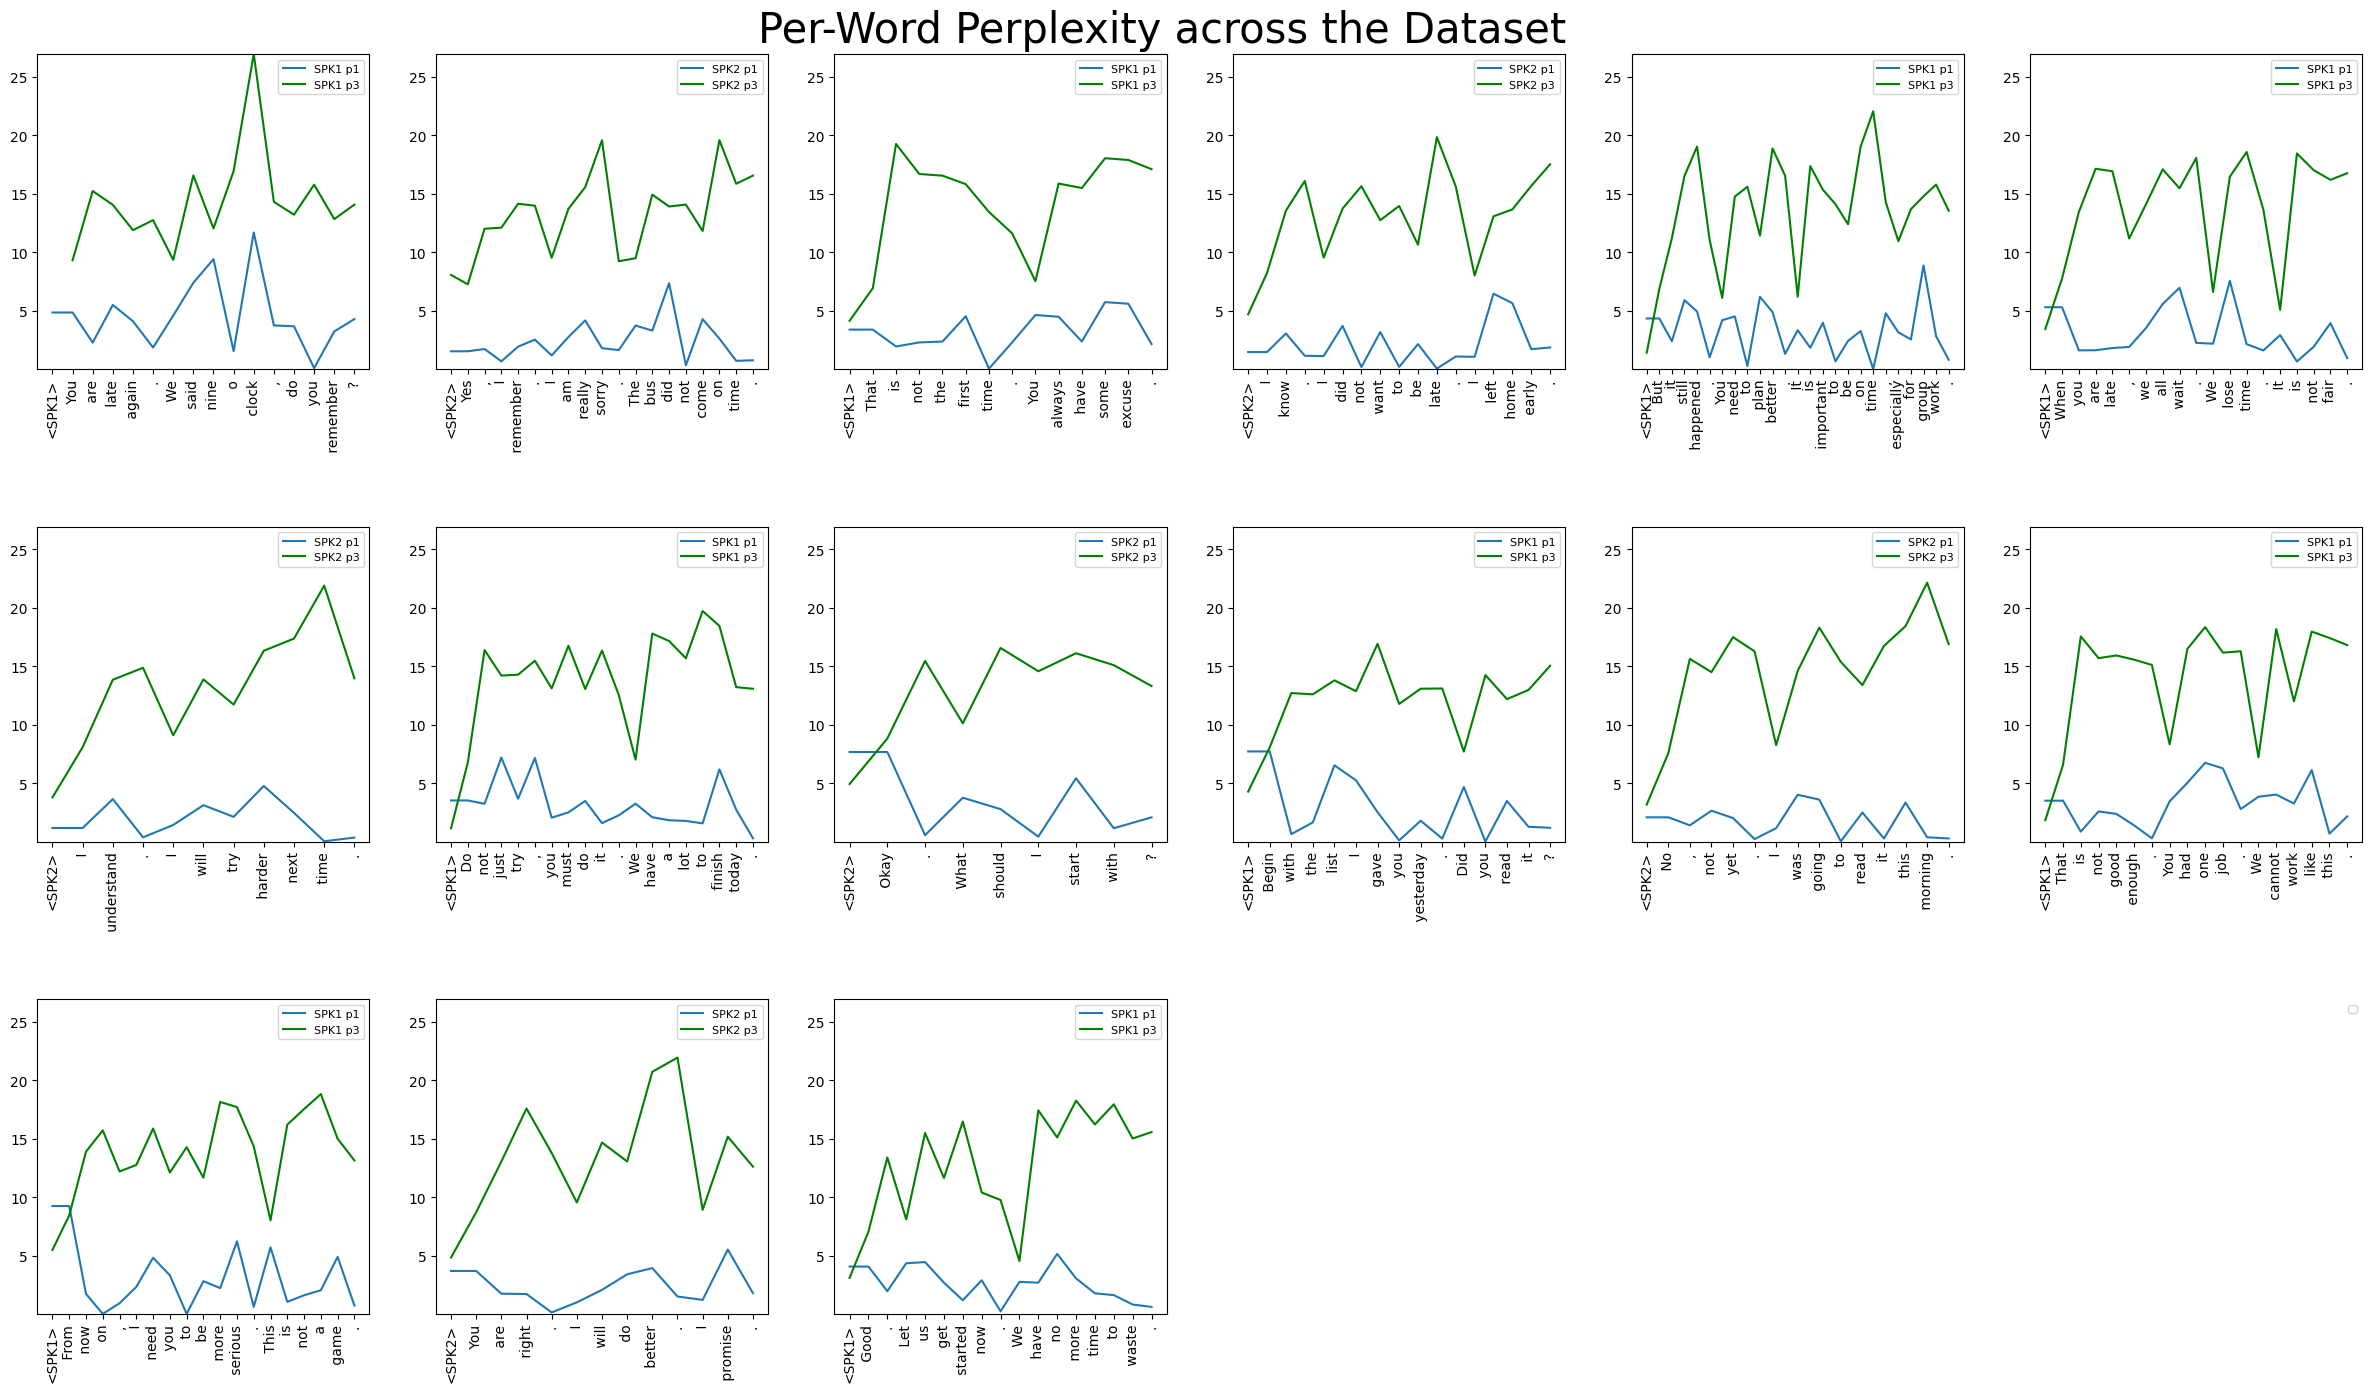

In [ ]:
# V4: New P3, New P1, use next token's perplexity for first element of p1, use <SPK1> and <SPK2>
tokens = [tokenizer(section, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for section in dialog]
perplexity_scores_p1 = p1_new(dialog)
perplexity_scores_p3 = p3_new(dialog)
perplexity_scores_p3_backup = perplexity_scores_p3.copy()
perplexity_scores_p3 = agg_p3_new(tokens, perplexity_scores_p3)

perplexity_scores_p1 = p1_use_next_token_ppl_for_speaker_begin_token(tokens, perplexity_scores_p1)
print("Correlation coef with new p3:")
print(np.corrcoef(perplexity_scores_p1[1:], perplexity_scores_p3[1:]))
print(f"Average P1 for speakers:{mean_p_per_speaker(tokens, perplexity_scores_p1)}")
print(f"Average P3 for speakers:{mean_p_per_speaker(tokens, perplexity_scores_p3)}")
print()
compute_graph_perplexity(tokens, perplexity_scores_p1, perplexity_scores_p3_backup, matches) # Shows the non-aggregated p3. note that now p3 and p1 are not equal because we changed the first element of p1 to use the next token's perplexity.

In [21]:
texts = [
    ("first dominant A", el_first_dominant),
    ("first dominant B", el_first_dominant_2),
    ("second dominant A", el_second_dominant),
    ("second dominant B", el_second_dominant_2),
    ]


for title, text in texts:
    print(f"################## {title} ##################")
    dialog, matches = preprocess(text)
    tokens = [tokenizer(section, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for section in dialog]
    perplexity_scores_p1 = p1_new(dialog)
    perplexity_scores_p3 = p3_new(dialog)
    perplexity_scores_p3_backup = perplexity_scores_p3.copy()
    perplexity_scores_p3 = agg_p3_new(tokens, perplexity_scores_p3)

    perplexity_scores_p1 = p1_use_next_token_ppl_for_speaker_begin_token(tokens, perplexity_scores_p1)
    print("Correlation coef with new p3:")
    print(np.corrcoef(perplexity_scores_p1[1:], perplexity_scores_p3[1:]))
    print(f"Average P1 for speakers:{mean_p_per_speaker(tokens, perplexity_scores_p1)}")
    print(f"Average P3 for speakers:{mean_p_per_speaker(tokens, perplexity_scores_p3)}")
    print()

################## first dominant A ##################


100%|██████████| 198/198 [00:01<00:00, 116.46it/s]


Correlation coef with new p3:
[[ 1.         -0.00320026]
 [-0.00320026  1.        ]]
Average P1 for speakers:(3.6579810487423208, 2.458576986541996)
Average P3 for speakers:(12.244101615944983, 12.157117044823092)

################## first dominant B ##################


100%|██████████| 246/246 [00:02<00:00, 104.69it/s]


Correlation coef with new p3:
[[1.         0.07449545]
 [0.07449545 1.        ]]
Average P1 for speakers:(3.2800725346499933, 2.340071463073324)
Average P3 for speakers:(13.589040801163156, 13.388689145695471)

################## second dominant A ##################


100%|██████████| 343/343 [00:03<00:00, 88.45it/s] 


Correlation coef with new p3:
[[1.         0.14280249]
 [0.14280249 1.        ]]
Average P1 for speakers:(2.513955917698639, 3.415544777613937)
Average P3 for speakers:(12.927738405306183, 15.096830435810173)

################## second dominant B ##################


100%|██████████| 212/212 [00:01<00:00, 107.22it/s]

Correlation coef with new p3:
[[1.         0.06956097]
 [0.06956097 1.        ]]
Average P1 for speakers:(3.0819733574175507, 3.6057393087906657)
Average P3 for speakers:(10.940658169689312, 12.865887347648123)

